## analysing the deep and surface ocean warming post net zero using ACCESS net zero runs

In [1]:
import warnings
warnings.filterwarnings('ignore')

In [2]:
import numpy as np
import os
import xarray as xr
import xcdat as xc

In [3]:
import matplotlib.pyplot as plt
import matplotlib as mpl
import matplotlib.ticker as mticker
import pandas as pd


In [4]:
print(os.environ.get(("ESMFMKFILE")))
print(os.environ.get(("PROJ_LIB")))

/opt/conda/analysis3-25.09/lib/esmf.mk
None


In [5]:

# os.environ['PROJ_LIB'] = '/g/data/xp65/public/apps/med_conda/envs/analysis3-24.04/share/proj'

In [6]:
import netCDF4
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from cartopy.util import add_cyclic_point
from cartopy.mpl.gridliner import LONGITUDE_FORMATTER, LATITUDE_FORMATTER

ERROR 1: PROJ: proj_create_from_database: Open of /g/data/xp65/public/./apps/med_conda/envs/analysis3-25.09/share/proj failed


In [7]:
import cmocean
from scipy import stats

In [8]:
mpl.rcParams['font.family'] = 'Droid Sans'
mpl.rcParams['font.size'] = 14
# Edit axes parameters
mpl.rcParams['axes.linewidth'] = 0.8
# Tick properties
mpl.rcParams['xtick.major.size'] = 5
mpl.rcParams['xtick.minor.size'] = 3
mpl.rcParams['xtick.major.width'] = 1
mpl.rcParams['xtick.direction'] = 'out'
mpl.rcParams['ytick.major.size'] = 5
mpl.rcParams['ytick.minor.size'] = 3
mpl.rcParams['ytick.major.width'] = 1
mpl.rcParams['ytick.direction'] = 'out'

In [9]:
import xesmf as xe

In [10]:
def plot_decorator():
    ax = plt.gca()
    
    # Minor ticks
    # ax.minorticks_on()
    # plt.tick_params(which='minor', axis='x', bottom=False)
    
    # Grid (light, behind data)
    ax.grid(color='gray', lw=0.4, alpha=0.1)
    
    # Remove top/right spines (Nature style)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    
    # Tight layout
    # plt.tight_layout()

In [11]:
from matplotlib.colors import BoundaryNorm as BM
# from matplotlib.colors import LogNorm as LM
import matplotlib.patches as mpatches


def plot_background(ax, draw_labels=False):
    ax.add_feature(cfeature.COASTLINE, alpha=0.9, lw=1.1)
    # ax.set_global()
    # ax.add_feature(cfeature.LAND, color='lightgray')
    # ax.add_feature(cfeature.OCEAN, color='lightgray')
    gl = ax.gridlines(draw_labels=draw_labels,
                      linewidth=1, color='gray', alpha=0.01, linestyle='--')
    gl.top_labels = False
    # gl.left_labels = False
    # gl.bottom_labels = False
    gl.right_labels = False
    gl.xlines = False
    # gl.xlocator = mticker.FixedLocator([-180, -45, 0, 45, 180])
    gl.xformatter = LONGITUDE_FORMATTER
    gl.yformatter = LATITUDE_FORMATTER
    gl.xlabel_style = {'size': 10, 'color': 'k'}
    gl.ylabel_style = {'size': 10, 'color': 'k'}
    return ax


def plot_maps(x, y, z, titles, labels, cmap, levels, pval = [], draw_winds=False, u_wnd=[], v_wnd=[], wind_scale=20, draw_contour=False, contour_data=[], contour_levels=[], contour_colors='gray', 
            nrows=1, ncols=3, figsize=(12,4), land_mask_list = [0], add_patch=False, add_patch_extra=False, hatch_type = 'insig', proj=ccrs.Robinson(central_longitude=160), 
            cbar_kwargs=dict(orientation='vertical', label='Precip', aspect=40, shrink=0.7, pad=0.05), draw_labels=False, draw_colorbar=True, auto_aspect=False):

    fig, axarr = plt.subplots(nrows=nrows, ncols=ncols, figsize=figsize, constrained_layout=False, subplot_kw={'projection':proj})
    
    axlist = axarr.flatten()
    
    for ax in axlist:
        if draw_labels:
            plot_background(ax, draw_labels)
        else:
            plot_background(ax)
        if auto_aspect:
            ax.set_aspect('auto')
        else:
            continue
    
    for i in range(len(z)):
        axlist[i].contourf(x, y, z[i], cmap = cmap, transform = ccrs.PlateCarree(central_longitude=0), levels=levels, extend='both')
        if draw_winds:
            wind_separation = 5
            q = axlist[i].quiver(x[::wind_separation, ::wind_separation], y[::wind_separation, ::wind_separation], u_wnd[i][::wind_separation, ::wind_separation], v_wnd[i][::wind_separation, ::wind_separation], scale=wind_scale, color='k', pivot='middle', transform=ccrs.PlateCarree())
            qk = ax.quiverkey(q, X=0.85, Y=0.9, U=1.0, label='1 m/s', labelpos='E', coordinates='axes')
            qk.text.set_bbox(dict(facecolor='white', edgecolor='k'))#, boxstyle='round,pad=0.3'))
        if draw_contour:
            axlist[i].contour(x, y, contour_data[i], cmap = None, levels=contour_levels, colors=contour_colors, transform = ccrs.PlateCarree(central_longitude=0), alpha=0.7)
        if i in land_mask_list:
            axlist[i].add_feature(cfeature.LAND, color = 'k', zorder=1)
        if pval != []:
            if hatch_type == 'insig':
                pval_plot = np.ma.masked_less_equal(pval[i], 0.05)
                axlist[i].pcolor(x, y, pval_plot, alpha = 0., hatch='/////', transform = ccrs.PlateCarree(central_longitude=0))
            elif hatch_type == 'sig':
                pval_plot = np.ma.masked_greater(pval[i], 0.05)
                axlist[i].pcolor(x, y, pval_plot, alpha = 0., hatch='...', transform = ccrs.PlateCarree(central_longitude=0))
        axlist[i].set_title(titles[i], fontdict={'fontsize':14})
        axlist[i].text(0.1, 1.05, labels[i], size=16, fontweight='bold', transform=axlist[i].transAxes)
        if add_patch:
            # axlist[i].add_patch(mpatches.Rectangle(xy=[120, -65], width=170, height=20,
            #                                 facecolor='none', edgecolor='k',
            #                                 transform=ccrs.PlateCarree()))
            axlist[i].add_patch(mpatches.Rectangle(xy=[190, -5], width=80, height=10,
                                            facecolor='none', edgecolor='k',
                                            transform=ccrs.PlateCarree()))
            axlist[i].add_patch(mpatches.Rectangle(xy=[140, -5], width=30, height=10,
                                            facecolor='none', edgecolor='k',
                                            transform=ccrs.PlateCarree()))
            # axlist[i].add_patch(mpatches.Rectangle(xy=[250, -30], width=40, height=20,
            #                                 facecolor='none', edgecolor='k',
            #                                 transform=ccrs.PlateCarree()))
            # axlist[i].add_patch(mpatches.Rectangle(xy=[140, 60], width=150, height=20,
            #                                             facecolor='none', edgecolor='tab:green', lw=1.5,
            #                                             transform=ccrs.PlateCarree()))
            # axlist[i].add_patch(mpatches.Rectangle(xy=[140, -80], width=150, height=20,
            #                                             facecolor='none', edgecolor='tab:green', lw=1.5,
            #                                             transform=ccrs.PlateCarree()))
        if add_patch_extra:
            axlist[i].add_patch(mpatches.Rectangle(xy=[190, 20], width=60, height=20,
                                                        facecolor='none', edgecolor='k', lw=1.5,
                                                        transform=ccrs.PlateCarree()))
            axlist[i].add_patch(mpatches.Rectangle(xy=[210, -40], width=60, height=30,
                                                        facecolor='none', edgecolor='k', lw=1.5,
                                                        transform=ccrs.PlateCarree()))
                    
    if draw_colorbar:
        norm = BM(levels, 256, extend='both')
        fig.colorbar(mpl.cm.ScalarMappable(norm = norm, cmap=cmap), ax = axlist, \
                    orientation = cbar_kwargs['orientation'], shrink=cbar_kwargs['shrink'], aspect = cbar_kwargs['aspect'], pad = cbar_kwargs['pad'], label = cbar_kwargs['label'], ticks=levels[::4])



def plot_single_map(x, y, z, title, label, cmap, levels, pval = [], draw_winds=False, u_wnd=[], v_wnd=[], wind_scale=20, draw_contour=False, contour_data=[], contour_levels=[], contour_colors='gray', 
                figsize=(12,4), land_mask_list = False, add_patch=False, add_patch_extra=False, hatch_type = 'insig', proj=ccrs.Robinson(central_longitude=160), 
                cbar_kwargs=dict(orientation='vertical', label='Precip', aspect=40, shrink=0.7, pad=0.05), draw_labels=False, draw_colorbar=True, auto_aspect=False):

    ax = plt.axes(projection=proj)
    if draw_labels:
        plot_background(ax, draw_labels)
    else:
        plot_background(ax)
    if auto_aspect:
        ax.set_aspect('auto')
    
    cf=ax.contourf(x, y, z, cmap = cmap, transform = ccrs.PlateCarree(central_longitude=0), levels=levels, extend='both')
    if draw_winds:
        wind_separation = 5
        q = ax.quiver(x[::wind_separation, ::wind_separation], y[::wind_separation, ::wind_separation], u_wnd.to_numpy()[::wind_separation, ::wind_separation], v_wnd.to_numpy()[::wind_separation, ::wind_separation], scale=wind_scale, \
        color='k', transform=ccrs.PlateCarree())
        qk = ax.quiverkey(q, X=0.85, Y=0.9, U=1.0, label='1 m/s', labelpos='E', coordinates='axes')
        qk.text.set_bbox(dict(facecolor='white', edgecolor='k'))#, boxstyle='round,pad=0.3'))
    if draw_contour:
        ax.contour(x, y, contour_data, cmap = None, levels=contour_levels, colors=contour_colors, transform = ccrs.PlateCarree(central_longitude=0), alpha=0.7)
    if land_mask_list:
        ax.add_feature(cfeature.LAND, color = 'k', zorder=1)
    if pval != []:
        if hatch_type == 'insig':
            pval_plot = np.ma.masked_less_equal(pval, 0.05)
            ax.pcolor(x, y, pval_plot, alpha = 0., hatch='/////', transform = ccrs.PlateCarree(central_longitude=0))
        elif hatch_type == 'sig':
            pval_plot = np.ma.masked_greater(pval, 0.05)
            ax.pcolor(x, y, pval_plot, alpha = 0., hatch='...', transform = ccrs.PlateCarree(central_longitude=0))
    ax.set_title(title, fontdict={'fontsize':14})
    ax.text(0.1, 1.05, label, size=16, fontweight='bold', transform=ax.transAxes)
    if add_patch:
        ax.add_patch(mpatches.Rectangle(xy=[190, -5], width=80, height=10,
                                        facecolor='none', edgecolor='k',
                                        transform=ccrs.PlateCarree()))
        ax.add_patch(mpatches.Rectangle(xy=[140, -5], width=30, height=10,
                                        facecolor='none', edgecolor='k',
                                        transform=ccrs.PlateCarree()))
    
    if add_patch_extra:
        ax.add_patch(mpatches.Rectangle(xy=[190, 20], width=60, height=20,
                                                    facecolor='none', edgecolor='k', lw=1.5,
                                                    transform=ccrs.PlateCarree()))
        ax.add_patch(mpatches.Rectangle(xy=[210, -40], width=60, height=30,
                                                    facecolor='none', edgecolor='k', lw=1.5,
                                                    transform=ccrs.PlateCarree()))
                    
    if draw_colorbar:
        norm = BM(levels, 256, extend='both')
        plt.colorbar(mpl.cm.ScalarMappable(norm = norm, cmap=cmap), ax = ax, \
                    orientation = cbar_kwargs['orientation'], shrink=cbar_kwargs['shrink'], aspect = cbar_kwargs['aspect'], pad = cbar_kwargs['pad'], label = cbar_kwargs['label'], ticks=levels[::4])

In [12]:
import sys

In [13]:
# sys.path.insert(0, '/home/563/as8561/PhD/net_zero_enso_pacific_changes/')

In [14]:
from functions import preproc_funcs as funcs

In [15]:
from functions import xr_lowess

### import data

In [16]:
ts_trans_orig = xr.open_dataset('/g/data/ob22/as8561/data/enso_trans_stable/sst_grad_res/access_lens/ACCESS-ESM1-5_ssp5_ts.nc').load()
ts_trans = funcs.calc_anom(ts_trans_orig, ts_trans_orig.sel(time = slice('1960', '1990')).sel(model = 'ACCESS-ESM1-5_r10i1p1f'))

In [17]:
ts_stable_orig = xr.open_dataset('/g/data/ob22/as8561/data/enso_trans_stable/sst_grad_res/access_stable/access_stable_ts.nc').load()
ts_stable = funcs.calc_anom_annual(ts_stable_orig, ts_trans_orig.sel(time = slice('1960', '1990')).sel(model = 'ACCESS-ESM1-5_r10i1p1f'))

In [18]:
thetao_zonal_trans = xr.open_mfdataset('/g/data/ob22/as8561/data/enso_trans_stable/sst_grad_res/access_lens/thetao_zonal/thetao_zonal_trans_r10.nc')
thetao_so_trans = xr.open_mfdataset('/g/data/ob22/as8561/data/enso_trans_stable/sst_grad_res/access_lens/thetao_so/thetao_so_trans_r10.nc')

In [19]:
thetao_zonal_stable2030 = xr.open_mfdataset('/g/data/ob22/as8561/data/enso_trans_stable/sst_grad_res/access_stable/thetao_zonal/access_stable_2030*.nc', concat_dim='time', combine='nested')
thetao_zonal_stable2045 = xr.open_mfdataset('/g/data/ob22/as8561/data/enso_trans_stable/sst_grad_res/access_stable/thetao_zonal/access_stable_2045*.nc', concat_dim='time', combine='nested')
thetao_zonal_stable2060 = xr.open_mfdataset('/g/data/ob22/as8561/data/enso_trans_stable/sst_grad_res/access_stable/thetao_zonal/access_stable_2060*.nc', concat_dim='time', combine='nested')


thetao_so_stable2030 = xr.open_mfdataset('/g/data/ob22/as8561/data/enso_trans_stable/sst_grad_res/access_stable/thetao_so/access_stable_2030*.nc', concat_dim='time', combine='nested')
thetao_so_stable2045 = xr.open_mfdataset('/g/data/ob22/as8561/data/enso_trans_stable/sst_grad_res/access_stable/thetao_so/access_stable_2045*.nc', concat_dim='time', combine='nested')
thetao_so_stable2060 = xr.open_mfdataset('/g/data/ob22/as8561/data/enso_trans_stable/sst_grad_res/access_stable/thetao_so/access_stable_2060*.nc', concat_dim='time', combine='nested')

In [20]:
thetao_zonal_stable2030

<xarray.Dataset> Size: 433kB
Dimensions:  (time: 10, lev: 36, j: 300)
Coordinates:
  * lev      (lev) float64 288B 5.0 15.0 25.0 ... 1.623e+03 1.802e+03 1.985e+03
  * j        (j) int32 1kB 0 1 2 3 4 5 6 7 8 ... 292 293 294 295 296 297 298 299
Dimensions without coordinates: time
Data variables:
    thetao   (time, lev, j) float32 432kB dask.array<chunksize=(1, 36, 300), meta=np.ndarray>

In [21]:
weights_model = np.cos(np.deg2rad(ts_trans.lat))

In [22]:
from cartopy import config

In [23]:
config

{'pre_existing_data_dir': PosixPath('.'),
 'data_dir': PosixPath('/home/563/as8561/.local/share/cartopy'),
 'cache_dir': PosixPath('/scratch/gb02/as8561/tmp/cartopy_cache_dir'),
 'repo_data_dir': PosixPath('/g/data/xp65/public/apps/med_conda/envs/analysis3-25.09/lib/python3.11/site-packages/cartopy/data'),
 'downloaders': {('shapefiles',
   'natural_earth'): <cartopy.io.shapereader.NEShpDownloader at 0x7f57193646d0>,
  ('shapefiles',
   'gshhs'): <cartopy.io.shapereader.GSHHSShpDownloader at 0x7f571b238ed0>}}

In [24]:
# xx, yy = np.meshgrid(ts_trans.lon.sel(lon = slice(100, 300)), ts_trans.lat.sel(lon = slice(100, 300)))

In [25]:
thetao_zonal_trans_anom = funcs.calc_anom(thetao_zonal_trans, thetao_zonal_trans.sel(time = slice('1960', '1990')))
thetao_so_trans_anom = funcs.calc_anom(thetao_so_trans, thetao_so_trans.sel(time = slice('1960', '1990'))).mean(('j'))

In [26]:
thetao_zonal_stable_anom2030 = thetao_zonal_stable2030.mean('time') - thetao_zonal_trans.sel(time = slice('1960', '1990')).mean(('time'))
thetao_zonal_stable_anom2045 = thetao_zonal_stable2045.mean('time') - thetao_zonal_trans.sel(time = slice('1960', '1990')).mean(('time'))
thetao_zonal_stable_anom2060 = thetao_zonal_stable2060.mean('time') - thetao_zonal_trans.sel(time = slice('1960', '1990')).mean(('time'))

thetao_so_stable_anom2030 = thetao_so_stable2030.mean('time') - thetao_so_trans.sel(time = slice('1960', '1990')).mean(('time', 'j'))
thetao_so_stable_anom2045 = thetao_so_stable2045.mean('time') - thetao_so_trans.sel(time = slice('1960', '1990')).mean(('time', 'j'))
thetao_so_stable_anom2060 = thetao_so_stable2060.mean('time') - thetao_so_trans.sel(time = slice('1960', '1990')).mean(('time', 'j'))

In [27]:
def compute_plotting_da(input_da, type='zonal'):
    """
    example for trans - thetao_zonal_trans_anom.sel(time = slice('2030', '2060')).mean('time').thetao
    example for stable - thetao_zonal_stable_anom2030.thetao
    """
    if type == 'zonal':
        ds_out = xe.util.cf_grid_2d(-0.75, 360, 1.5, -90, 90, 1.5)
        input_da = input_da.expand_dims(dim = dict(i = 360))
        input_da['j'] = np.linspace(-90, 90, len(input_da.j))
        input_da['i'] = np.linspace(0, 360, len(input_da.i))
        input_da = input_da.rename(dict(i='lon', j='lat'))
        regridder = xe.Regridder(input_da, ds_out, 'bilinear', periodic=True, ignore_degenerate=True)
        plotting_da = regridder(input_da).mean(('lon'))
    elif type == 'merid':
        ds_out = xe.util.cf_grid_2d(-0.75, 360, 1.5, -80, 40, 1.5)
        input_da = input_da.expand_dims(dim = dict(j = 40))
        input_da['j'] = np.linspace(-80, 40, len(input_da.j))
        input_da['i'] = np.linspace(0, 360, len(input_da.i))
        input_da = input_da.rename(dict(i='lon', j='lat'))
        regridder = xe.Regridder(input_da, ds_out, 'bilinear', periodic=True, ignore_degenerate=True)
        plotting_da = regridder(input_da).mean(('lat'))
    return plotting_da

In [28]:
# plot_cuboid_contours(zz.to_numpy(), zz.lon.to_numpy(), zz.lat.to_numpy(), plotting_da.thetao.to_numpy(), plotting_da.lat.to_numpy(), plotting_da.lev.to_numpy(), plotting_da_test.thetao.to_numpy(), plotting_da_test.lon.to_numpy(), plotting_da_test.lev.to_numpy())

In [29]:
from mpl_toolkits.mplot3d import Axes3D
import itertools
from matplotlib.collections import LineCollection, PolyCollection
from cartopy.mpl.patch import geos_to_path

In [30]:
# def add_basemap(ax, proj=ccrs.PlateCarree(central_longitude=180), type='land'):
#     if type == 'land':
#         feature = cfeature.NaturalEarthFeature('physical', 'land', '110m')
#         concat = lambda iterable: list(itertools.chain.from_iterable(iterable))
#         geoms = feature.geometries()
#         geoms = [proj.project_geometry(geom, feature.crs) for geom in geoms]
#         paths = concat(geos_to_path(geom) for geom in geoms)
#         polys = concat(path.to_polygons() for path in paths)
#         pc = PolyCollection(polys, edgecolor='none', facecolor='k', closed=False)
#         ax.add_collection3d(pc, zs=0, zdir='z')
#     elif type == 'coastline':
#         feature = cfeature.NaturalEarthFeature('physical', 'coastine', '110m')
#         geoms = feature.geometries()
#         geoms = [proj.project_geometry(geom, feature.crs) for geom in geoms]
#         paths = list(itertools.chain.from_iterable(geos_to_path(geom) for geom in geoms))
#         segments = []
#         for path in paths:
#             vertices = [vertex for vertex, _ in path.iter_segments()]
#             vertices = np.asarray(vertices)
#             segments.append(vertices)
        
#         lc = LineCollection(segments, color='black')
# #         ax.add_collection3d(lc, zs=0, zdir='z')


In [31]:
import shapely.geometry as sgeom

def add_basemap(ax, proj=ccrs.PlateCarree(central_longitude=180), type='land',
                lon_min=-180, lon_max=180, lat_min=-80, lat_max=90):
    # Create clipping box polygon in lon/lat coordinates
    clipping_box = sgeom.box(lon_min, lat_min, lon_max, lat_max)  # minx, miny, maxx, maxy
    
    concat = lambda iterable: list(itertools.chain.from_iterable(iterable))

    if type == 'land':
        feature = cfeature.NaturalEarthFeature('physical', 'land', '110m')
        geoms = feature.geometries()
        
        clipped_geoms = []
        for geom in geoms:
            # Project geom to target CRS
            proj_geom = proj.project_geometry(geom, feature.crs)
            # Clip geometry with box in lon/lat
            clipped = proj_geom.intersection(clipping_box)
            if not clipped.is_empty:
                clipped_geoms.append(clipped)
        
        paths = concat(geos_to_path(geom) for geom in clipped_geoms)
        polys = concat(path.to_polygons() for path in paths)
        pc = PolyCollection(polys, edgecolor='none', facecolor='k', closed=False, alpha=0.8)
        ax.add_collection3d(pc, zs=0, zdir='z')

    elif type == 'coastline':
        feature = cfeature.NaturalEarthFeature('physical', 'coastline', '110m')
        geoms = feature.geometries()
        clipped_geoms = []
        for geom in geoms:
            proj_geom = proj.project_geometry(geom, feature.crs)
            clipped = proj_geom.intersection(clipping_box)
            if not clipped.is_empty:
                clipped_geoms.append(clipped)
        
        paths = concat(geos_to_path(geom) for geom in clipped_geoms)
        segments = []
        for path in paths:
            vertices = [vertex for vertex, _ in path.iter_segments()]
            vertices = np.asarray(vertices)
            segments.append(vertices)
        
        lc = LineCollection(segments, color='black')
        ax.add_collection3d(lc, zs=0, zdir='z')



In [32]:
def plot_single_cuboid_contours(surface_da, zonal_da, merid_da, levels = np.linspace(-1, 3, 21), figsize=(8,5), basemap_type='land'):
    fig = plt.figure(figsize=figsize)
    ax = fig.add_subplot(111, projection='3d', xlim=[-180, 180], ylim=[-80, 90], zlim = [0, 2000], computed_zorder=False)
    #########
    # zz = surface_da.ts.sel(lat = slice(-80, 90)).isel(model=0).sel(time = slice('2045', '2075')).mean('time')#.sel(lon = slice(100, 300))
    zz = surface_da
    X, Y = np.meshgrid(zz.lon, zz.lat)
    ax.contourf(X-180, Y, zz, levels=levels, zdir='z', offset=0, cmap='RdBu_r', extend='both')
    #########
    xx = zonal_da
    Y, Z = np.meshgrid(xx.lat, xx.lev)
    ax.contourf(xx, Y, Z, levels=levels, zdir='x', offset=180, cmap='RdBu_r', extend='both')
    #########
    yy = merid_da
    X, Z = np.meshgrid(yy.lon, yy.lev)
    cf = ax.contourf(X-180, yy, Z, levels=levels, zdir='y', offset=-80, cmap='RdBu_r', extend='both')
    ax.invert_zaxis()
    #########
    add_basemap(ax, type=basemap_type)
    ax.set_yticklabels(['', '50$^{o}$S', '0$^{o}$', '50$^{o}N$'])
    ax.set_xticklabels(['', '80$^{o}$E', '180$^{o}$W', '80$^{o}W$'])
    fig.colorbar(cf, ax=ax, pad=0.1, aspect=40, fraction=0.02, ticks=levels[::2], label='Temperature anomaly (degC)')
    ax.view_init(40, -45, 0)
    # ax.set_box_aspect(None, zoom=1.0)
    ax.set_box_aspect((1.2,1.0,0.8))

In [33]:
def plot_cuboid_contours(
    surface_da_list, zonal_da_list, merid_da_list,
    cmap='RdBu_r',
    levels=np.linspace(-1, 3, 21),
    figsize=(12, 6), basemap_type='land',
    nrows=1, ncols=1,
    box_aspect=(2, 1, 1.2),  # (x, y, z) scaling
    hspace=0.05, wspace=0.05,  # control gaps
):
    """
    Plot cuboid contour plots with optional multiple subplots and a common colorbar.
    """
    fig = plt.figure(figsize=figsize)
    axes = []
    cf_last = None  # keep a handle to the last contourf for colorbar

    for idx, (surface_da, zonal_da, merid_da) in enumerate(
        zip(surface_da_list, zonal_da_list, merid_da_list)
    ):
        ax = fig.add_subplot(
            nrows, ncols, idx + 1,
            projection='3d',
            xlim=[-180, 180], ylim=[-80, 90], zlim=[0, 2000],
            computed_zorder=False
        )

        # --- surface map (z=0) ---
        X, Y = np.meshgrid(surface_da.lon, surface_da.lat)
        ax.contourf(X - 180, Y, surface_da, levels=levels, zdir='z', offset=0,
                    cmap=cmap, extend='both')

        # --- zonal section (x=180) ---
        Y, Z = np.meshgrid(zonal_da.lat, zonal_da.lev)
        ax.contourf(zonal_da, Y, Z, levels=levels, zdir='x',
                    offset=180, cmap=cmap, extend='both')

        # --- meridional section (y=-80) ---
        X, Z = np.meshgrid(merid_da.lon, merid_da.lev)
        cf_last = ax.contourf(X - 180, merid_da, Z, levels=levels, zdir='y',
                              offset=-80, cmap=cmap, extend='both')

        # --- basemap overlay ---
        add_basemap(ax, type=basemap_type)

        # --- labels ---
        ax.set_yticks([-60, -30, 0, 30, 60])
        ax.set_yticklabels(['60$^{o}$S', '30$^{o}$S', '0$^{o}$', '30$^{o}N$', '60$^{o}$N'], fontsize=8)
        ax.set_xticks([x - 180 for x in [60, 120, 180, 240, 300]])
        ax.set_xticklabels(['60$^{o}$E', '120$^{o}$E', '180$^{o}$W', '120$^{o}$W', '60$^{o}W$'], fontsize=8)
        ax.set_zticks(np.arange(0, 2500, 500))
        ax.set_zticklabels(np.arange(0, 2500, 500), fontsize=8)
        
        # Flip depth
        ax.invert_zaxis()
        # --- view & aspect ---
        ax.view_init(40, -45, 0)
        ax.set_box_aspect(box_aspect)

        axes.append(ax)

    fig.subplots_adjust(wspace=wspace, hspace=hspace)
    # --- common colorbar ---
    cbar = fig.colorbar(
        cf_last, ax=axes, orientation='vertical',
        pad=0.11, aspect=40, fraction=0.02, shrink=0.6,
        ticks=levels[::2], label='Temperature anomaly (°C)'
    )
    return fig, axes, cbar

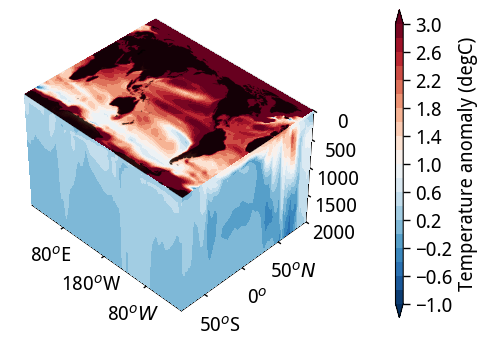

In [36]:
sst = ts_trans.ts.sel(time = slice('2045', '2075'), lat=slice(-80, 90)).isel(model=0).mean(('time'))
ocean_temp_zonal = compute_plotting_da(thetao_zonal_trans_anom.sel(time = slice('2015', '2045')).mean('time').thetao, type='zonal').sel(lat = slice(-81, 90))
ocean_temp_so = compute_plotting_da(thetao_so_trans_anom.sel(time = slice('2015', '2045')).mean('time').thetao, type='merid')
plot_single_cuboid_contours(sst, ocean_temp_zonal, ocean_temp_so, figsize=(10,4), basemap_type='land')

In [37]:
sst_list = [
    ts_trans.ts.sel(time = slice('2045', '2075'), lat=slice(-80, 90)).isel(model=0).mean(('time')),
    ts_trans.ts.sel(time = slice('2030', '2060'), lat=slice(-80, 90)).isel(model=0).mean(('time')),
    ts_trans.ts.sel(time = slice('2015', '2045'), lat=slice(-80, 90)).isel(model=0).mean(('time')),
]

ocean_temp_zonal_list = [
    compute_plotting_da(thetao_zonal_trans_anom.sel(time = slice('2045', '2075')).mean('time').thetao, type='zonal').sel(lat = slice(-81, 90)),
    compute_plotting_da(thetao_zonal_trans_anom.sel(time = slice('2030', '2060')).mean('time').thetao, type='zonal').sel(lat = slice(-81, 90)),
    compute_plotting_da(thetao_zonal_trans_anom.sel(time = slice('2015', '2045')).mean('time').thetao, type='zonal').sel(lat = slice(-81, 90)),
]

ocean_temp_merid_list = [
    compute_plotting_da(thetao_so_trans_anom.sel(time = slice('2045', '2075')).mean('time').thetao, type='merid'),
    compute_plotting_da(thetao_so_trans_anom.sel(time = slice('2030', '2060')).mean('time').thetao, type='merid'),
    compute_plotting_da(thetao_so_trans_anom.sel(time = slice('2015', '2045')).mean('time').thetao, type='merid'),
]

(<Figure size 800x1100 with 4 Axes>,
 [<Axes3D: >, <Axes3D: >, <Axes3D: >],
 <matplotlib.colorbar.Colorbar at 0x7f04bc3c8ed0>)

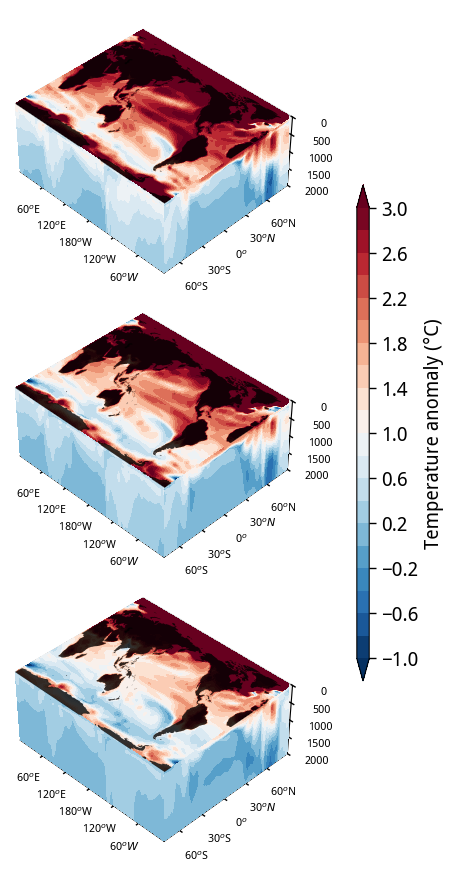

In [38]:
plot_cuboid_contours(
    sst_list, ocean_temp_zonal_list, ocean_temp_merid_list,
    cmap='RdBu_r',
    levels=np.linspace(-1, 3, 21),
    figsize=(8, 11), basemap_type='land',
    nrows=3, ncols=1,
    box_aspect=(1.4, 1.2, 0.6),  # (x, y, z) scaling
    hspace=0.02, wspace=0.02,  # control gaps
)

In [39]:
sst_list_stable = [
    ts_stable.ts.sel(model = '2060', lat = slice(-80, 90)).mean(('time')),
    ts_stable.ts.sel(model = '2045', lat = slice(-80, 90)).mean(('time')),
    ts_stable.ts.sel(model = '2030', lat = slice(-80, 90)).mean(('time')),
]

ocean_temp_zonal_list_stable = [
    compute_plotting_da(thetao_zonal_stable_anom2060.thetao, type='zonal').sel(lat = slice(-81, 90)),
    compute_plotting_da(thetao_zonal_stable_anom2045.thetao, type='zonal').sel(lat = slice(-81, 90)),
    compute_plotting_da(thetao_zonal_stable_anom2030.thetao, type='zonal').sel(lat = slice(-81, 90)),
]

ocean_temp_merid_list_stable = [
    compute_plotting_da(thetao_so_stable_anom2060.thetao, type='merid'),
    compute_plotting_da(thetao_so_stable_anom2045.thetao, type='merid'),
    compute_plotting_da(thetao_so_stable_anom2030.thetao, type='merid'),
]

(<Figure size 800x1100 with 4 Axes>,
 [<Axes3D: >, <Axes3D: >, <Axes3D: >],
 <matplotlib.colorbar.Colorbar at 0x7f0550071f10>)

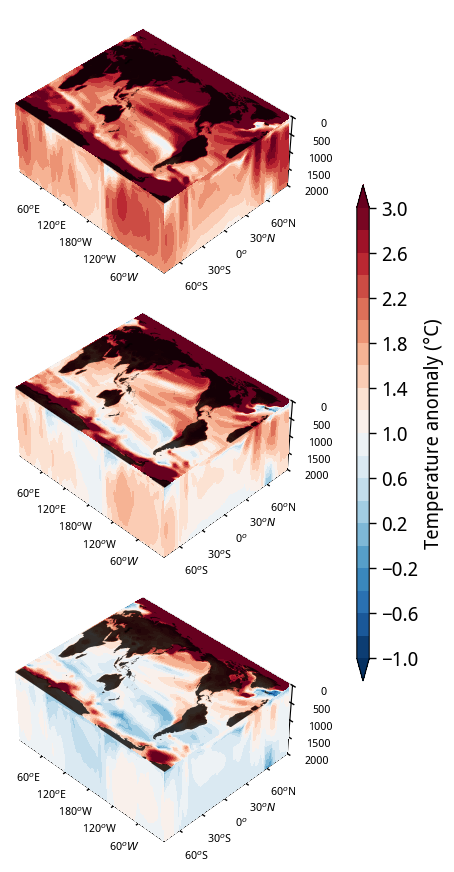

In [40]:
plot_cuboid_contours(
    sst_list_stable, ocean_temp_zonal_list_stable, ocean_temp_merid_list_stable,
    cmap='RdBu_r',
    levels=np.linspace(-1, 3, 21),
    figsize=(8, 11), basemap_type='land',
    nrows=3, ncols=1,
    box_aspect=(1.4, 1.2, 0.6),  # (x, y, z) scaling
    hspace=0.02, wspace=0.02,  # control gaps
)

In [41]:
sst_list_diff = [
    sst_list_stable[0] - sst_list[0],
    sst_list_stable[1] - sst_list[1],
    sst_list_stable[2] - sst_list[2],
]

ocean_temp_zonal_list_diff = [
    ocean_temp_zonal_list_stable[0] - ocean_temp_zonal_list[0],
    ocean_temp_zonal_list_stable[1] - ocean_temp_zonal_list[1],
    ocean_temp_zonal_list_stable[2] - ocean_temp_zonal_list[2],
]

ocean_temp_merid_list_diff = [
    ocean_temp_merid_list_stable[0] - ocean_temp_merid_list[0],
    ocean_temp_merid_list_stable[1] - ocean_temp_merid_list[1],
    ocean_temp_merid_list_stable[2] - ocean_temp_merid_list[2],
]

(<Figure size 800x1100 with 4 Axes>,
 [<Axes3D: >, <Axes3D: >, <Axes3D: >],
 <matplotlib.colorbar.Colorbar at 0x7f04a8568ed0>)

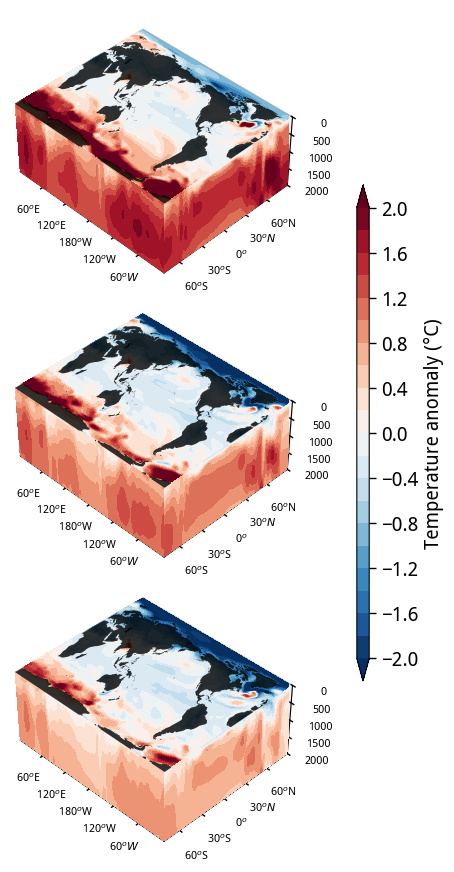

In [42]:
plot_cuboid_contours(
    sst_list_diff, ocean_temp_zonal_list_diff, ocean_temp_merid_list_diff,
    cmap='RdBu_r',
    levels=np.linspace(-2, 2, 21),
    figsize=(8, 11), basemap_type='land',
    nrows=3, ncols=1,
    box_aspect=(1.4, 1.2, 0.6),  # (x, y, z) scaling
    hspace=0.02, wspace=0.02,  # control gaps
)